<div id="bg-slide">
    <center>
    <h1>DFT introduction Homework</h1>
<center>
<br>
<table>
  <tr>
      <td><p><h1>Team Rutgers</h1></p><p><h2>(Michele, Ezekiel & Valeria)</h2></p><p><h2>Rutgers University-Newark</h2></p></td> 
      <td><img src="../figures/logos/ASESMA_logo.png" width=300 height=300 /></td>
  </tr>
  <tr>
    <td></td>
    <td>Work alone or in a group</td>
  </tr>
</table>
<br>
<h3>Retrieve this presentation at:</h3>
<br>
<center>https://github.com/asesma-org/miniASESMA2026</center>

<br>

<center><h3> mini ASESMA 2026 $\bullet$ Accra, Ghana $\bullet$ June 17, 2026</h3></center>
</div>


### To run this tutorial in google colab click the following link :

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/asesma-org/miniASESMA2026/blob/main/Week1/Day3/DFT_intro_2_homework.ipynb)


In [ ]:
## Uncomment the following lines for Colab. IMPORTANT NOTE: install first qepy and then dftpy
# !pip install qepy f90wrap==0.2.16

In [ ]:
# !python -m pip install "git+https://github.com/Quantum-MultiScale/DFTpy.git@dev"

In [2]:
from IPython.display import IFrame
import numpy as np
import matplotlib.pyplot as plt
from ase.build import molecule
from pyscf import gto

In [3]:
L=10; X = np.linspace(start=0,stop=L,num=1000,endpoint=False)
def pw(x,G):
    return 1.0/np.sqrt(L)*np.exp(1j*2*np.pi*G*x)
def gto(x,center,alpha):
    return np.sqrt(alpha/np.pi)*np.exp(-alpha*(x-center)**2)

# Homework 1
A dive into plane waves.
 - Find the wavefunctions that solve the time-independent Schrödinger equation of a single particle of mass $m=1$au in a periodic 1D box of size $L$. Use Hartree atomic units ($\hbar = 1$, $e=1$, $4\pi\varepsilon_0=1$) throughout.
 - Remember, with PBCs the continuity conditions are $\psi(x+L)=\psi(x)$.
 - Show that the $G$ points allowed are only $G_k = 2\pi \frac{k}{L}$ with $k=0,\pm 1, \pm 2, \ldots$.

# This is what PWs look like

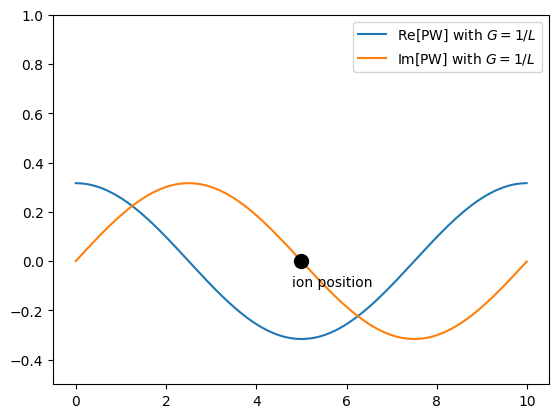

In [4]:
fig = plt.figure()#(figsize=(8,5))
plt.plot(X,np.real(pw(X,G=1/L)), label=r"Re[PW] with $G=1/L$")
plt.plot(X,np.imag(pw(X,G=1/L)), label=r"Im[PW] with $G=1/L$")
plt.plot(5, 0, 'ko', markersize=10); plt.text(x=4.8,y=-0.1,s="ion position")
plt.ylim([-.5,1]); plt.legend()

# How many PWs are needed? (1d case with FFTs)

 - First, let's discretize a 1d box of length $L=10$ au into $N$ points, $\{x_k=\frac{k}{N}L\}$
<center><img src="../figures/science/line.png" width=400 /></center>

In [7]:
N=7; L=10; print("Number of points: N =", N, " and length L =", L)

Number of points: N = 7  and length L = 10


In [11]:
print("These are the real-space points:\n")
x = np.linspace(start=0,stop=L,num=N, endpoint=False)
print(x)

These are the real-space points:

[0.         1.42857143 2.85714286 4.28571429 5.71428571 7.14285714
 8.57142857]


#### You can change `N` if you'd like.

## Let's find the available reciprocal space

 - We generate all the available $G$ points according to <a href="https://numpy.org/doc/stable/reference/routines.fft.html">FFT</a>: $~e^{iG_j x_k}=e^{i\left(\frac{2\pi j}{L}\right) \left(\frac{k}{N}L\right)}=e^{i2\pi \frac{jk}{N}}$

 - Thus: as $x_k=\frac{k}{N}L$, it must be that $G_j = 2\pi \frac{j}{L}$ with $j=0,\pm 1, \pm 2,\ldots \pm \frac{N}{2}$
 - In units of $j$:
<center><img src="../figures/science/lineg.png" width=400 /></center>

In [12]:
print("The reciprocal space points:\n")
G = np.fft.fftfreq(N,d=L/N); G

The reciprocal space points:



array([ 0. ,  0.1,  0.2,  0.3, -0.3, -0.2, -0.1])

<center>
    <div class="alert alert-success">
        Note: higher $N$ &rarr; higher maximum value of $G$
    </div>
</center>

# Effect of a PW cutoff

Now compute the Fourier transform of a Gaussian $f(x)$, $\tilde f(G)$

$$
\tilde f(G) = \int dx f(x) e^{-iG x} \simeq \frac{L}{N}\sum_{i=0}^{N-1} f_i e^{-i G x_i}
$$

In [13]:
f = gto(x,center=5,alpha=1)

tilde_f = np.fft.fft(f)*L/N

Now compute the inverse Fourier transform of the Gaussian on a new domain (not the original N points)

$$
f(x) = \frac{1}{L}\sum_{i=0}^{N-1} \tilde f_i e^{i G_i
x}
$$

In [14]:
def gto_in_pw(fft,G,X):
    N=len(G); f_X = np.zeros_like(X,dtype=np.complex128)
    for i in range(N):
        f_X += fft[i]*np.exp(1j*2*np.pi*G[i]*X)  
    return np.real(f_X)/L

# Plot of the effect of a PW cutoff

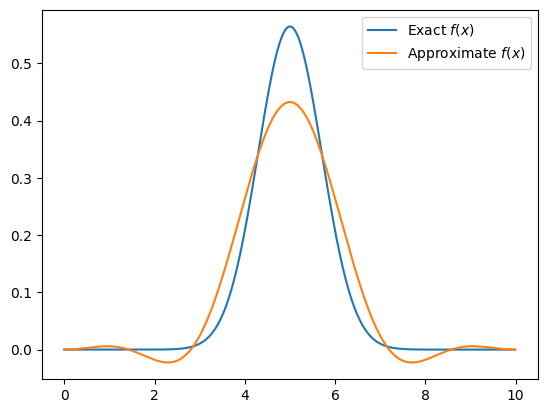

In [15]:
plt.plot(X,gto(X,center=5,alpha=1),label=r"Exact $f(x)$")
plt.plot(X,gto_in_pw(tilde_f,G,X),label=r"Approximate $f(x)$")
plt.legend()

# Homework 2
 - What is an appropriate number of PWs for representing $f(x)$ defined int he previous cell? Discuss with your peers and provide a quantitative justification.
 - Express the answer in terms of the "maximum kinetic energy" of the basis set $T_{max}=\left(\frac{G_{max}^2}{2}\right)$ in units of Ha. Convert to Ry. This is also known as `PW cutoff`